Shape of Dataset:
(4692, 10)

Data Types:
Date                          object
Name of State / UT            object
Latitude                     float64
Longitude                    float64
Total Confirmed cases        float64
Death                         object
Cured/Discharged/Migrated    float64
New cases                      int64
New deaths                     int64
New recovered                  int64
dtype: object

First 10 Rows:
         Date Name of State / UT  Latitude  Longitude  Total Confirmed cases  \
0  2020-01-30             Kerala   10.8505    76.2711                    1.0   
1  2020-01-31             Kerala   10.8505    76.2711                    1.0   
2  2020-02-01             Kerala   10.8505    76.2711                    2.0   
3  2020-02-02             Kerala   10.8505    76.2711                    3.0   
4  2020-02-03             Kerala   10.8505    76.2711                    3.0   
5  2020-02-04             Kerala   10.8505    76.2711                    3.0  

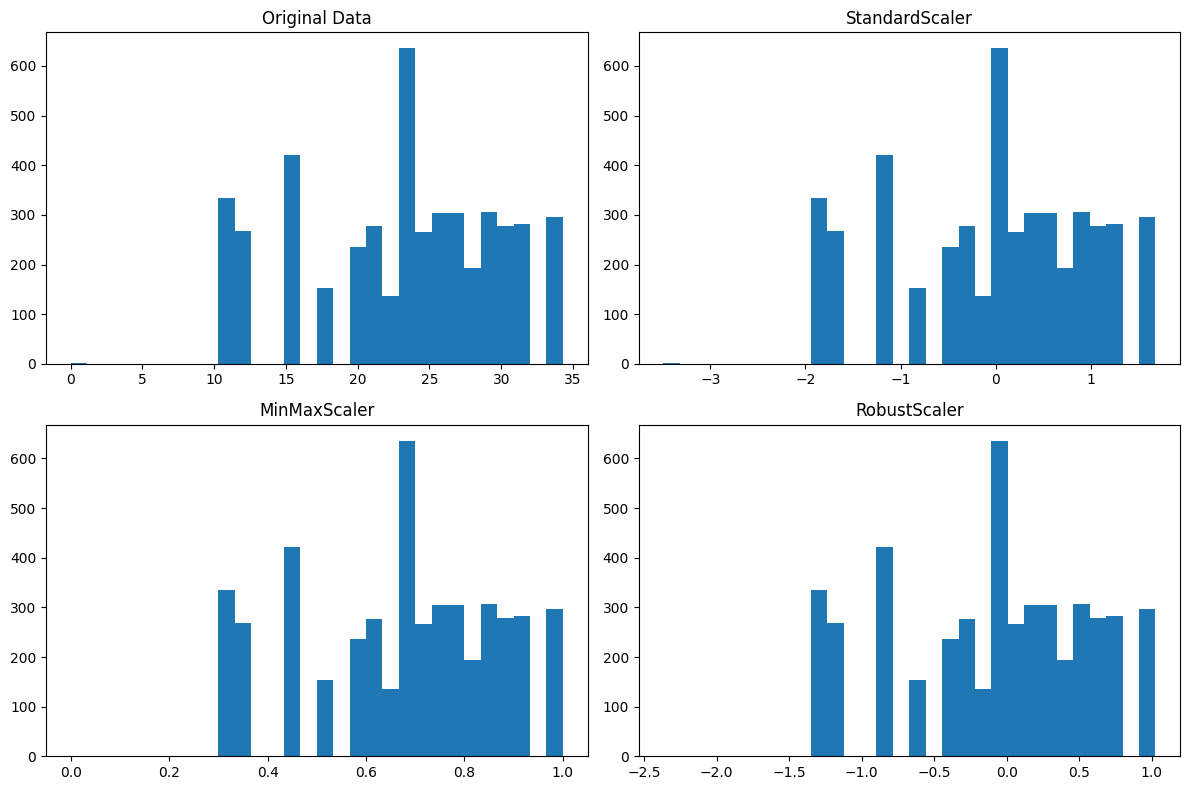


Top 5 Features:
Total Confirmed cases
Cured/Discharged/Migrated
New cases
New recovered
StandardScaler

Feature Scores
                     Feature         Score
9             StandardScaler  7.543529e+17
4                  New cases  1.168301e+02
6              New recovered  8.354366e+01
2      Total Confirmed cases  6.818728e+01
3  Cured/Discharged/Migrated  4.945657e+01

Why These Features Matter
1. They have the strongest statistical relationship with the target.
2. They improve prediction accuracy.
3. They reduce unnecessary features.
4. They decrease model training time.
5. They help prevent overfitting.


In [1]:
# ==============================
# Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

# ==============================
# Load Dataset
# ==============================

url = "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"

df = pd.read_csv(url)

# ==============================
# Dataset Information
# ==============================

print("Shape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 10 Rows:")
print(df.head(10))

# ==============================
# Data Cleaning
# ==============================

df = df.drop_duplicates()
df = df.fillna(0)

# ==============================
# Label Encoding
# ==============================

categorical_cols = df.select_dtypes(include="object").columns

if len(categorical_cols) > 0:
    label = LabelEncoder()
    df["Label_Encoded"] = label.fit_transform(df[categorical_cols[0]])

print("\nLabel Encoding Completed")

# ==============================
# One Hot Encoding
# ==============================

onehot_df = pd.get_dummies(df, columns=[categorical_cols[0]], dtype=int)

print("\nOne Hot Encoding Completed")

# ==============================
# Ordinal Encoding
# ==============================

ordinal = OrdinalEncoder()

df["Ordinal_Encoded"] = ordinal.fit_transform(df[[categorical_cols[0]]])

print("\nOrdinal Encoding Completed")

# ==============================
# Trade-offs
# ==============================

print("\nTrade-offs")
print("LabelEncoder : Simple but may imply order.")
print("OneHotEncoder : Best for nominal data but creates many columns.")
print("OrdinalEncoder : Good only when categories have natural order.")

# ==============================
# Select Numeric Column
# ==============================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Ignore encoded columns
ignore = ["Label_Encoded", "Ordinal_Encoded"]

numeric_cols = [col for col in numeric_cols if col not in ignore]

numeric_feature = numeric_cols[0]

print("\nNumeric Column Used for Scaling:", numeric_feature)

# ==============================
# Feature Scaling
# ==============================

standard = StandardScaler()
minmax = MinMaxScaler()
robust = RobustScaler()

df["StandardScaler"] = standard.fit_transform(df[[numeric_feature]])

df["MinMaxScaler"] = minmax.fit_transform(df[[numeric_feature]])

df["RobustScaler"] = robust.fit_transform(df[[numeric_feature]])

# ==============================
# Plot Distributions
# ==============================

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(df[numeric_feature], bins=30)
plt.title("Original Data")

plt.subplot(2,2,2)
plt.hist(df["StandardScaler"], bins=30)
plt.title("StandardScaler")

plt.subplot(2,2,3)
plt.hist(df["MinMaxScaler"], bins=30)
plt.title("MinMaxScaler")

plt.subplot(2,2,4)
plt.hist(df["RobustScaler"], bins=30)
plt.title("RobustScaler")

plt.tight_layout()
plt.show()

# ==============================
# SelectKBest
# ==============================

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 6:

    X = numeric_df.iloc[:, :-1]
    y = numeric_df.iloc[:, -1]

    selector = SelectKBest(score_func=f_regression, k=5)

    selector.fit(X, y)

    selected_features = X.columns[selector.get_support()]

    print("\nTop 5 Features:")

    for feature in selected_features:
        print(feature)

    scores = pd.DataFrame({
        "Feature": X.columns,
        "Score": selector.scores_
    })

    print("\nFeature Scores")
    print(scores.sort_values(by="Score", ascending=False).head(5))

else:
    print("\nDataset does not contain enough numeric columns for SelectKBest.")

# ==============================
# Why These Features Matter
# ==============================

print("\nWhy These Features Matter")
print("1. They have the strongest statistical relationship with the target.")
print("2. They improve prediction accuracy.")
print("3. They reduce unnecessary features.")
print("4. They decrease model training time.")
print("5. They help prevent overfitting.")